In [1]:
!hostnamectl

 Static hostname: gpue05.delta.ncsa.illinois.edu
       Icon name: computer-server
         Chassis: server 🖳
      Machine ID: 7160fa58ed57460fad63c00d1f2ce1bc
         Boot ID: 0ca164f76e7a47b9bd93cac2a859cc39
Operating System: ]8;;https://www.redhat.com/Red Hat Enterprise Linux 9.4 (Plow)]8;;     
     CPE OS Name: cpe:/o:redhat:enterprise_linux:9::baseos
          Kernel: Linux 5.14.0-427.91.1.el9_4.x86_64
    Architecture: x86-64
Firmware Version: CUXD670_5.32_v2.06


In [ ]:
# # Check JAX sees the GPU
# import jax
# print(jax.devices())  # should show CudaDevice(id=0)
# print(jax.default_backend())  # should show 'gpu'

# # Check CUDA version
# import subprocess
# print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

# # Check JAX/jaxlib versions
# import jaxlib
# print(f"JAX version: {jax.__version__}")
# print(f"jaxlib version: {jaxlib.__version__}")

# # Quick GPU computation test
# import jax.numpy as jnp
# x = jnp.ones((1000, 1000))
# print(f"Array device: {x.devices()}")  # should show CudaDevice

In [2]:
# tmp 
import os
tmp_dir = '/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp'
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=8"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Cache compiled kernels to disk (create this directory first)
cache_dir = os.path.join(tmp_dir, "asachan_jax_cache")
os.makedirs(cache_dir, exist_ok=True)
os.environ["JAX_COMPILATION_CACHE_DIR"] = cache_dir

In [3]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [4]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [5]:
rna_path = '/projects/bgdb/asachan/datasets/SKM_ageing_human/All_Cell_Types.h5ad'
rna_path_filtered = '/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_all_cell_types.h5ad'

In [6]:
rna_adata = sc.read_h5ad(rna_path_filtered)
rna_adata

AnnData object with n_obs × n_vars = 172396 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

In [ ]:
# subset to samples of interest
#adata = rna_adata[rna_adata.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9', 'P13', 'P5', 'OM5', 'OM7'])].copy()

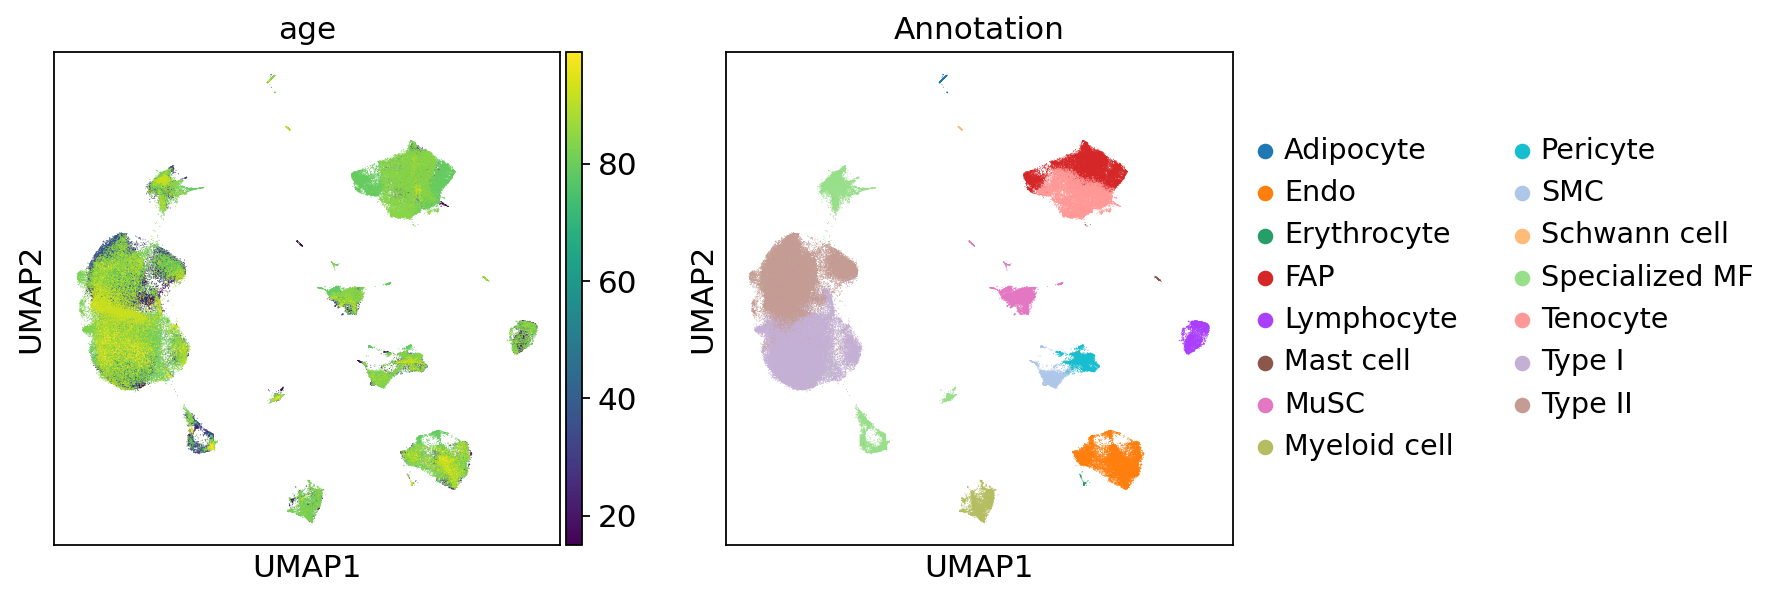

In [7]:
sc.pl.umap(rna_adata, color=['age', 'Annotation'])

In [8]:
#subset to type 2
rna_adata = rna_adata[rna_adata.obs['Annotation'] == 'Type II'].copy()

#### Lower bound on number of cells per age

In [9]:
age_counts = rna_adata.obs['age'].value_counts()
valid_ages = age_counts[age_counts >= 500].index

rna_adata = rna_adata[rna_adata.obs['age'].isin(valid_ages)].copy()

# Verify
print(rna_adata.obs['age'].value_counts())

age
15.0    10004
34.0     8633
80.0     5550
45.0     4735
92.0     4657
82.0     3285
18.0     2269
38.0     1807
84.0     1594
89.0     1155
88.0      767
79.0      726
85.0      505
Name: count, dtype: int64


#### Upper bound on number of cells per age

In [10]:
n_cells_downsample = 5000
adatas = []

for age, idx in rna_adata.obs.groupby('age').groups.items():
    subset = rna_adata[idx].copy()
    if subset.shape[0] > n_cells_downsample:
        sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
    adatas.append(subset)

rna_adata = ad.concat(adatas)
del adatas

# Verify
print(rna_adata.obs['age'].value_counts())

age
15.0    5000
34.0    5000
80.0    5000
45.0    4735
92.0    4657
82.0    3285
18.0    2269
38.0    1807
84.0    1594
89.0    1155
88.0     767
79.0     726
85.0     505
Name: count, dtype: int64


In [ ]:
# # save 
#rna_adata.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_all_cell_types.h5ad')

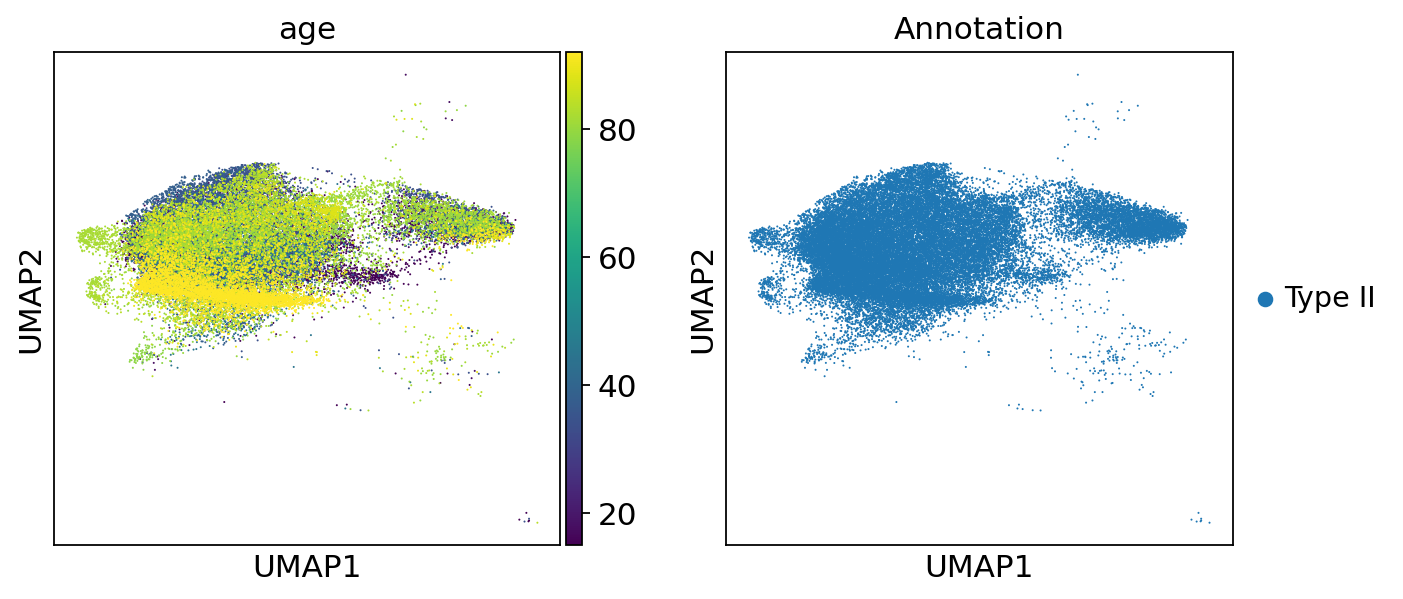

In [11]:
sc.pl.umap(rna_adata, color=['age', 'Annotation'])

In [12]:
# make temporal info numeric
def adapt_time(x):
    if x["age_pop"] == "young_pop":
        return 1.5
    if x["age_pop"] == "old_pop":
        return 3.5
    raise ValueError

rna_adata.obs["age_pop"] = rna_adata.obs.apply(adapt_time, axis=1).astype("category")

In [13]:
rna_adata.obs['age_pop'].value_counts()

age_pop
1.5    18811
3.5    17689
Name: count, dtype: int64

In [14]:
# instantiate temporal OT problem
tp0 = TemporalProblem(rna_adata)
tp0 = tp0.prepare(time_key="age_pop")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  


In [15]:
import networkx as nx

batch_column = "age_pop"
batch1, batch2 = 1.5, 3.5

indices = np.where(
    (rna_adata.obs[batch_column] == batch1) | (rna_adata.obs[batch_column] == batch2)
)[0]

adata_subset = rna_adata[indices]
sc.pp.neighbors(adata_subset, n_neighbors=30, use_rep="X_pca")

G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
assert nx.is_connected(G)

# if graph not connect check if there is a major disconnectivity due to batch effect in the latent space
# n_components = nx.number_connected_components(G)
# print(f"Number of connected components: {n_components}")
# # Check sizes of each component
# sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
# print(f"Component sizes: {sizes}")

In [16]:
df = pd.DataFrame(
    index=adata_subset.obs_names,
    columns=adata_subset.obs_names,
    data=adata_subset.obsp["connectivities"].todense().astype("float"),
)

In [17]:
t1, t2 = 1.5, 3.5
prob = tp0[t1, t2]
expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)
Gdf = df.loc[expected, expected].astype(float)
prob.set_graph_xy(Gdf, t=100.0)

In [19]:
import scanpy as sc
sc.settings.verbosity = 3  # shows more detail
# epsilon: entropic regularization strength
#batch_size is for sinkhorn iterations, the grpah omputation and transfer to gpu (compilation) takes most time
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7, batch_size=5000) 

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(18811, 17689)].                                


W0304 22:02:00.928936  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:02:04.896831  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:02:12.908286  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:02:14.081703  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:02:14.489009  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:02:15.120792  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:02:15.250573  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:02:16.181112  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22

### Save objects after computation

In [21]:
import cloudpickle
with open(f'{tmp_dir}/tp0_5k_type2.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

Saved!


In [22]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)

sp.save_npz(os.path.join(tmp_dir, "T_1.5_3.5.npz"), T_15_35_csr)

W0304 22:12:57.421555  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:12:58.285857  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:12:58.543003  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:13:03.809318  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:13:04.632755  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:13:04.682924  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:13:04.753775  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:13:04.857345  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


### Visualize

In [24]:
rna_adata.obs["age"] = rna_adata.obs["age"].astype("category")
order_chronological = rna_adata.obs["age"].cat.categories.tolist()
order_chronological

[15.0, 18.0, 34.0, 38.0, 45.0, 79.0, 80.0, 82.0, 84.0, 85.0, 88.0, 89.0, 92.0]

W0304 22:23:47.253875  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:23:59.363355  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:24:00.892103  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:24:01.002540  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:24:01.105850  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:24:01.503107  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:24:01.897289  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:24:02.109619  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22

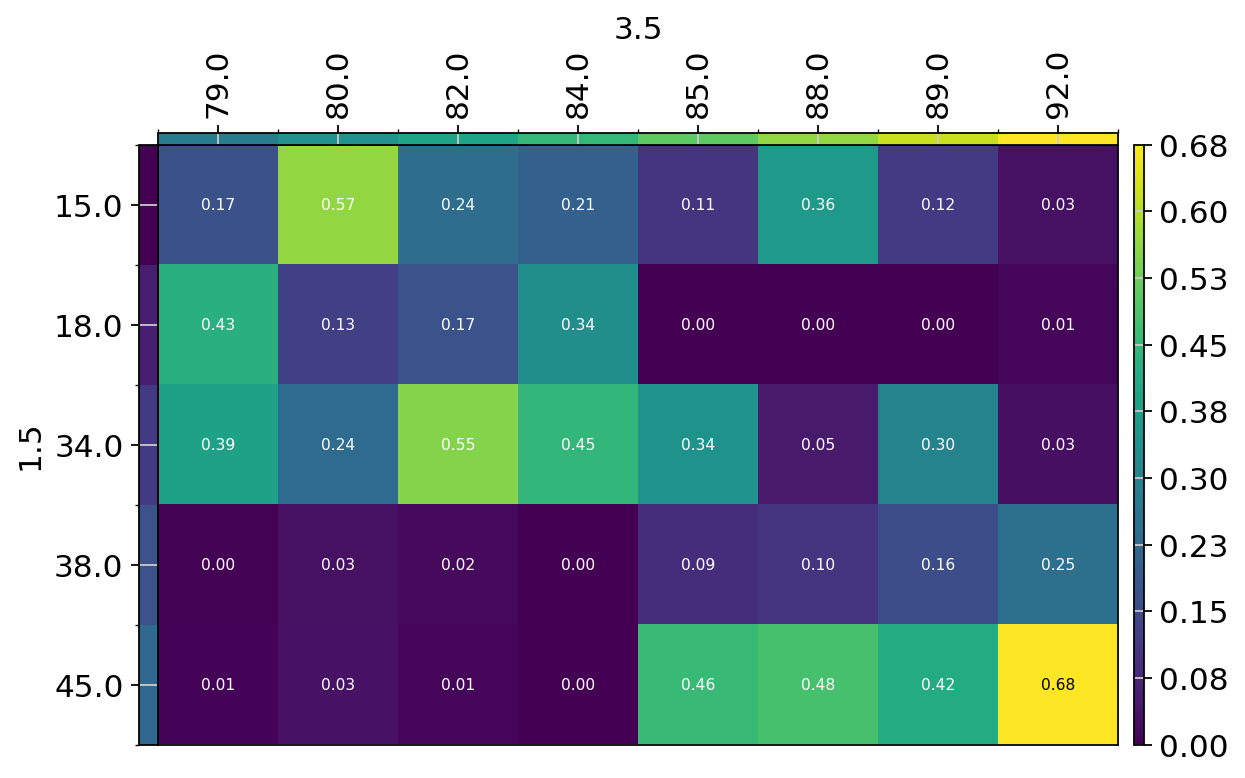

In [25]:
#aggregating the transport matrix by chronological age
# ANSCESTORS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"age": order_chronological},
    {"age": order_chronological},
    forward=False,
    key_added="transitions_1.5_3.5_large",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_large",
)
plt.tight_layout()
plt.show()

W0304 22:33:24.196396  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:33:24.232602  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:33:27.550796  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:33:27.779845  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:33:28.375681  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:33:28.417221  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:33:28.450387  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:33:28.468691  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22

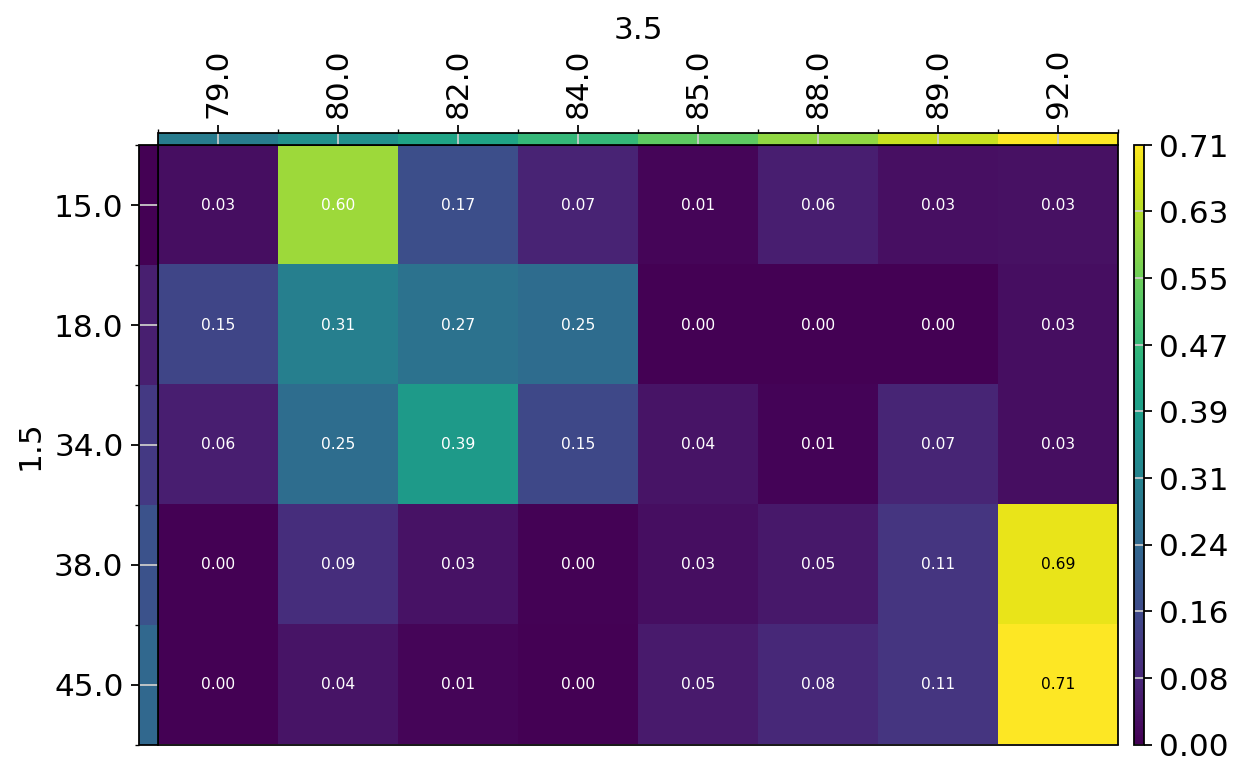

In [29]:
#aggregating the transport matrix by chronological age
# DESCENDANTS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"age": order_chronological},
    {"age": order_chronological},
    forward=True,
    key_added="transitions_1.5_3.5",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5",
)
plt.tight_layout()
plt.show()

W0304 22:40:36.409273  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:40:37.992135  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:40:38.054017  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:40:38.075100  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:40:38.447616  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:40:47.292107  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0304 22:40:47.467475  253393 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


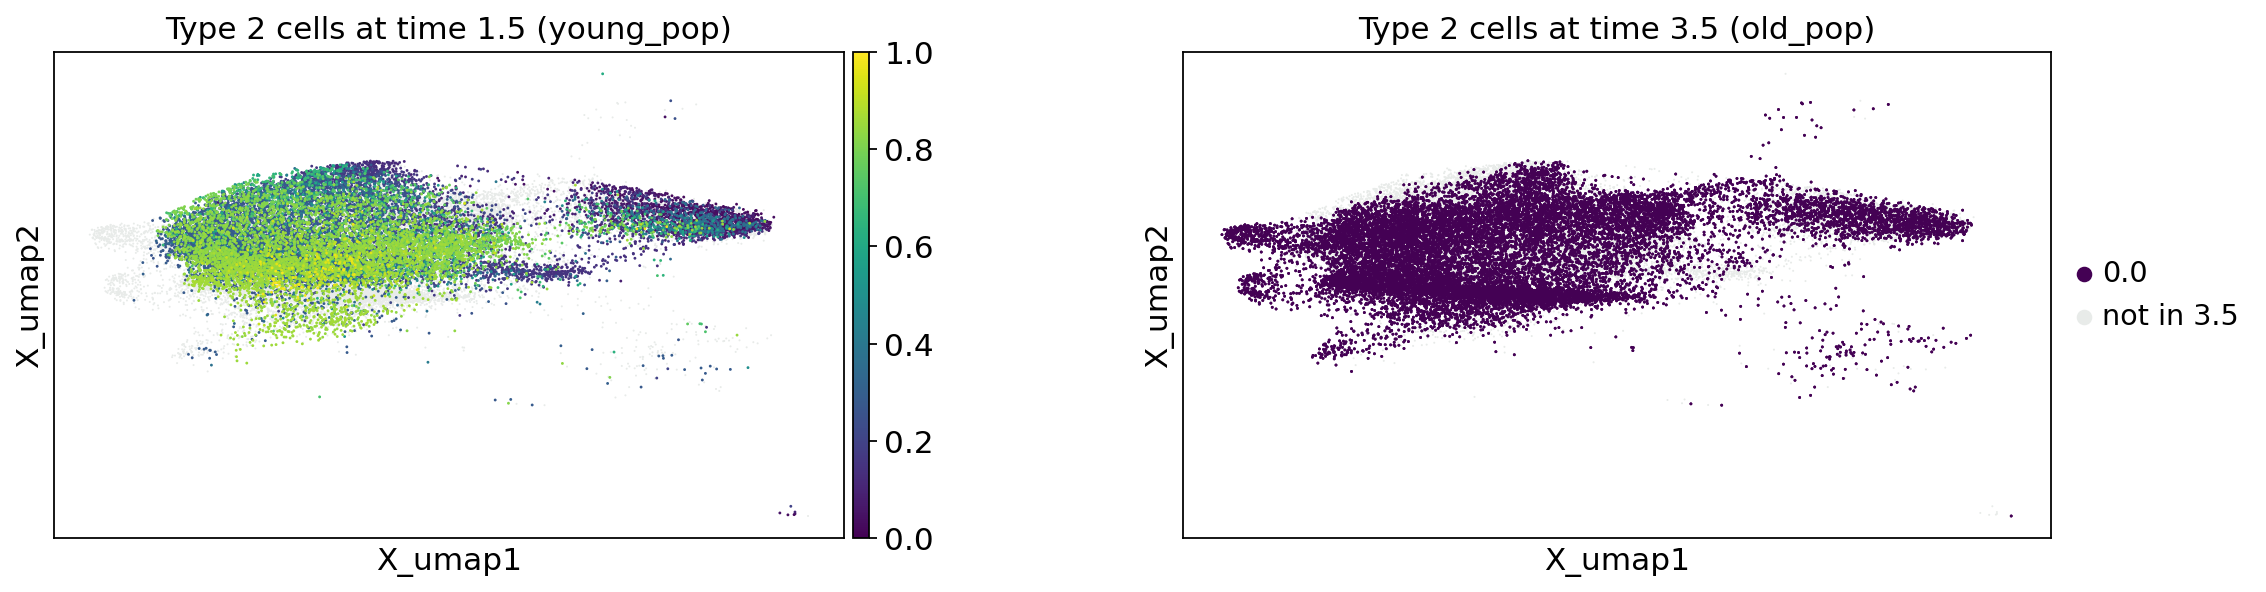

In [31]:
tp0.pull(source=1.5, target=3.5, data="age")
fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

mpl.pull(
    tp0,
    time_points=[1.5],
    basis="X_umap",
    ax=axes[0],
    title=["Type 2 cells at time 1.5 (young_pop)"],
)

mpl.pull(
    tp0,
    time_points=[3.5],
    basis="X_umap",
    ax=axes[1],
    title=["Type 2 cells at time 3.5 (old_pop)"],
)

fig.subplots_adjust(wspace=0.3)

In [32]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"age": order_chronological},
    target_groups={"age": order_chronological},
    threshold=0.05,
    order_annotations=order_chronological[::-1],
    normalize=True,
)

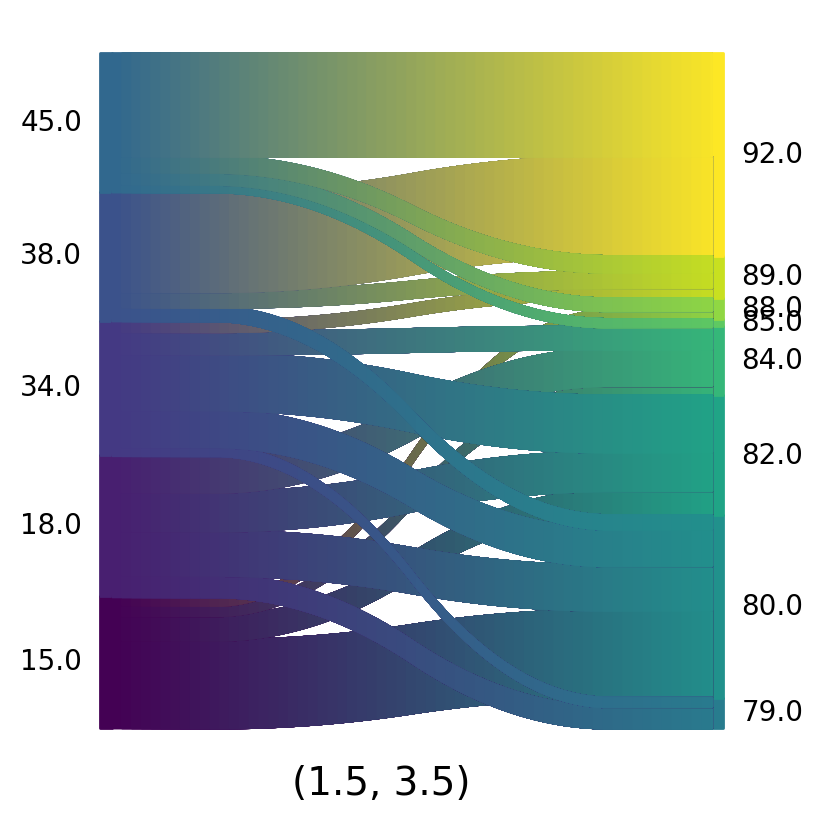

In [33]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

## Identifying driver genes

In [ ]:
X_orig = tp0.adata.X.copy()

#check mean and min and max of X
print(X_orig.mean(), X_orig.min(), X_orig.max())

0.04610748 0.0 8.778708


In [40]:
sc.pp.normalize_total(tp0.adata)
sc.pp.log1p(tp0.adata)

normalizing counts per cell
    finished (0:00:20)


In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def driver_tfs_for_subset(
    tp,
    old_age: float,
    young_age: float,
    t_young: float = 1.5,
    t_old: float = 3.5,
    age_col: str = "age",
    timepoint_col: str = "age_pop",
    features: str = "human",
    qval_thresh: float = 0.05,
    corr_thresh: float = 0.1,
) -> pd.DataFrame:
    """
    Compute driver TFs for the transition from a young_age subpopulation
    to an old_age subpopulation using optimal transport pull-back.

    Parameters
    ----------
    tp          : moscot TemporalProblem (already fitted)
    old_age     : chronological age to pull back FROM (target at t_old)
    young_age   : chronological age to subset AT t_young (source)
    t_young     : pseudotime of the source timepoint (default 1.5)
    t_old       : pseudotime of the target timepoint (default 3.5)
    age_col     : obs column name for chronological age
    timepoint_col: obs column name for pseudotime
    features    : TF list passed to compute_feature_correlation
    qval_thresh : q-value cutoff for significance filter
    corr_thresh : absolute correlation cutoff for significance filter

    Returns
    -------
    pd.DataFrame with columns:
        corr, pval, qval, ci_low, ci_high, significant
    sorted by correlation descending, indexed by gene name.
    """
    key = f"{int(old_age)}_{int(young_age)}_pull"

    # --- 1. Pull back old_age cells at t_old onto all cells at t_young ---
    tp.pull(
        t_young,
        t_old,
        data=age_col,
        subset=old_age,
        key_added=key,
        normalize=True,
    )

    pull_sum = tp.adata.obs[key].sum()
    print(f"[pull] key='{key}' | weight sum = {pull_sum:.4f}")
    if pull_sum == 0:
        raise ValueError(
            f"All pull weights are 0. Check that age {old_age} exists at "
            f"timepoint {t_old} in obs['{age_col}']."
        )

    # --- 2. Report weight stats for young_age cells specifically ---
    mask = (
        (tp.adata.obs[age_col] == young_age) &
        (tp.adata.obs[timepoint_col] == t_young)
    )
    n_cells = mask.sum()
    print(f"[subset] {n_cells} cells with age={young_age} at t={t_young}")
    if n_cells == 0:
        raise ValueError(
            f"No cells found with age={young_age} at timepoint {t_young}."
        )
    print(tp.adata.obs.loc[mask, key].describe())

    # --- 3. Compute feature correlation across all t_young cells ---
    drivers = tp.compute_feature_correlation(
        obs_key=key,
        features=features,
        annotation={timepoint_col: [t_young, t_old]},
    )

    # --- 4. Rename columns to be age-pair specific ---
    prefix = f"{int(old_age)}_{int(young_age)}"
    drivers.columns = [c.replace(key, prefix) for c in drivers.columns]
    corr_col = f"{prefix}_corr"
    qval_col = f"{prefix}_qval"

    # --- 5. Add significance flag and sort ---
    drivers["significant"] = (
        (drivers[qval_col] < qval_thresh) &
        (drivers[corr_col].abs() > corr_thresh)
    )

    drivers = drivers.dropna(subset=[corr_col]).sort_values(corr_col, ascending=False)

    n_sig = drivers["significant"].sum()
    print(f"\n[result] {n_sig} significant drivers "
          f"(qval<{qval_thresh}, |corr|>{corr_thresh})")

    top_pos = drivers.head(10).style.set_caption(
        f"TOP 10 POSITIVE DRIVERS (age {young_age} → {old_age})"
    ).background_gradient(subset=[corr_col], cmap="Reds")

    top_neg = drivers.tail(10).iloc[::-1].style.set_caption(
        f"TOP 10 NEGATIVE DRIVERS (age {young_age} → {old_age})"
    ).background_gradient(subset=[corr_col], cmap="Blues_r")

    from IPython.display import display
    display(top_pos)
    display(top_neg)

    return drivers, drivers.head(10), drivers.tail(10).iloc[::-1]

In [62]:
def plot_driver_tfs(
    drivers: pd.DataFrame,
    young_age: float,
    old_age: float,
    n_label: int = 15,
    qval_thresh: float = 0.05,
    corr_thresh: float = 0.1,
    figsize: tuple = (8, 6),
) -> None:
    """
    Volcano plot for driver TFs from driver_tfs_for_subset output.

    Parameters
    ----------
    drivers     : DataFrame returned by driver_tfs_for_subset
    young_age   : source chronological age (for axis labels/title)
    old_age     : target chronological age (for axis labels/title)
    n_label     : number of top genes to annotate
    qval_thresh : q-value threshold line to draw
    corr_thresh : correlation threshold lines to draw
    figsize     : figure size
    """
    prefix = f"{int(old_age)}_{int(young_age)}"
    corr_col = f"{prefix}_corr"
    qval_col = f"{prefix}_qval"

    log_q = -np.log10(drivers[qval_col] + 1e-300)
    sig = drivers["significant"]

    fig, ax = plt.subplots(figsize=figsize)

    # All non-significant genes
    ax.scatter(
        drivers.loc[~sig, corr_col], log_q[~sig],
        alpha=0.3, s=5, color="grey", label="not significant"
    )
    # Significant genes
    ax.scatter(
        drivers.loc[sig, corr_col], log_q[sig],
        alpha=0.6, s=8, color="steelblue", label="significant"
    )

    # Top positive and negative annotated genes
    top_pos = drivers.head(n_label)
    top_neg = drivers.tail(n_label).iloc[::-1]

    for subset, color in [(top_pos, "red"), (top_neg, "darkorange")]:
        ax.scatter(
            subset[corr_col],
            -np.log10(subset[qval_col] + 1e-300),
            color=color, s=12, zorder=5
        )
        for gene, row in subset.iterrows():
            ax.annotate(
                gene,
                (row[corr_col], -np.log10(row[qval_col] + 1e-300)),
                fontsize=6.5, ha="left", va="bottom",
                xytext=(3, 2), textcoords="offset points"
            )

    # Threshold lines
    ax.axvline(0, linestyle="--", color="black", linewidth=0.8)
    ax.axvline(corr_thresh, linestyle=":", color="grey", linewidth=0.8)
    ax.axvline(-corr_thresh, linestyle=":", color="grey", linewidth=0.8)
    ax.axhline(
        -np.log10(qval_thresh), linestyle=":", color="grey", linewidth=0.8
    )

    ax.set_xlabel(f"Correlation with transport weight (age {young_age} → {old_age})")
    ax.set_ylabel("-log10(q-value)")
    ax.set_title(f"Driver TFs: Age {young_age} → Age {old_age}")
    ax.legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()

In [66]:
# Get driver TFs for age-38 (young) → age-92 (old) transition
drivers_38_92, top_pos, top_neg = driver_tfs_for_subset(
    tp=tp0,
    old_age=92.0,
    young_age=38.0,
    t_young=1.5,
    t_old=3.5,
)

[pull] key='92_38_pull' | weight sum = 2.0000
[subset] 1807 cells with age=38.0 at t=1.5
count    1.807000e+03
mean     1.386794e-04
std      7.979712e-05
min      2.302025e-31
25%      5.405251e-05
50%      1.916322e-04
75%      2.000625e-04
max      2.023221e-04
Name: 92_38_pull, dtype: float64

[result] 117 significant drivers (qval<0.05, |corr|>0.1)


,92_38_corr,92_38_pval,92_38_qval,92_38_ci_low,92_38_ci_high,significant
GLIS3,0.226004,0.000000,0.000000,0.216246,0.235716,True
ZNF385D,0.219702,0.000000,0.000000,0.209916,0.229444,True
PUM3,0.196492,0.000000,0.000000,0.186609,0.206335,True
BDP1,0.187940,0.000000,0.000000,0.178024,0.197817,True
CHD2,0.154093,0.000000,0.000000,0.144062,0.164093,True
EEF1D,0.152989,0.000000,0.000000,0.142954,0.162992,True
TCF7L1,0.143673,0.000000,0.000000,0.133611,0.153705,True
BPTF,0.140801,0.000000,0.000000,0.130731,0.150842,True
PDCD11,0.132015,0.000000,0.000000,0.121921,0.142081,True
JAZF1,0.126804,0.000000,0.000000,0.116697,0.136885,True


,92_38_corr,92_38_pval,92_38_qval,92_38_ci_low,92_38_ci_high,significant
TP63,-0.402810,0.000000,0.000000,-0.411369,-0.394180,True
RORA,-0.292345,0.000000,0.000000,-0.301699,-0.282934,True
MEF2A,-0.258790,0.000000,0.000000,-0.268336,-0.249192,True
FOS,-0.253784,0.000000,0.000000,-0.263357,-0.244160,True
FOXO1,-0.247984,0.000000,0.000000,-0.257588,-0.238331,True
EGR1,-0.231548,0.000000,0.000000,-0.241234,-0.221816,True
SNRNP70,-0.208441,0.000000,0.000000,-0.218234,-0.198607,True
NFIA,-0.203123,0.000000,0.000000,-0.212938,-0.193267,True
TCF4,-0.186470,0.000000,0.000000,-0.196354,-0.176549,True
PDLIM5,-0.186220,0.000000,0.000000,-0.196104,-0.176297,True


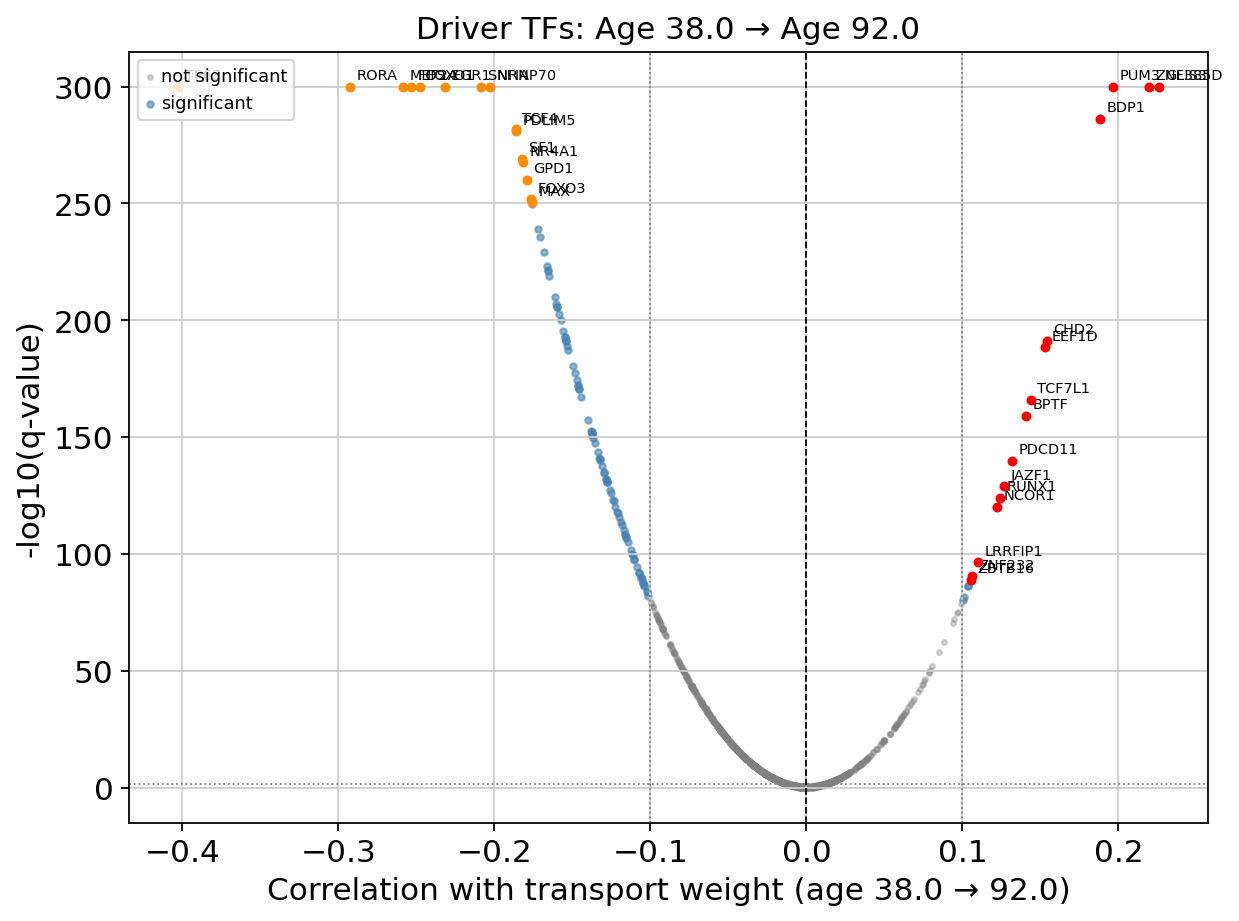

In [67]:
# Volcano plot
plot_driver_tfs(drivers_38_92, young_age=38.0, old_age=92.0)